In [ ]:
import pandas as pd
import sys
from pathlib import Path

BASE_DIR = Path("../").resolve()

sys.path.append(str(BASE_DIR))
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

BASE_DIR = Path("../")

In [11]:
# Processed dataset used for training
movie_tags = pd.read_csv(BASE_DIR / "data/movie_tags.csv")

# Original TMDB dataset
tmdb_movies = pd.read_csv(BASE_DIR / "data/tmdb_5000_movies.csv")

# Credits dataset
tmdb_credits = pd.read_csv(BASE_DIR / "data/tmdb_5000_credits.csv")

## Dataset Overview

The project uses two datasets:

- **TMDB Movies Dataset** – Original movie metadata.
- **Processed Movie Tags Dataset** – Cleaned dataset used to train the recommendation model.

In [12]:
print("Processed Dataset Shape:", movie_tags.shape)
print("TMDB Movies Shape:", tmdb_movies.shape)
print("Credits Shape:", tmdb_credits.shape)

Processed Dataset Shape: (4806, 8)
TMDB Movies Shape: (4803, 20)
Credits Shape: (4803, 4)


In [13]:
movie_tags.head()

,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di...","['Action', 'Adventure', 'Fantasy', 'ScienceFic...","['cultureclash', 'future', 'spacewar', 'spacec...","['SamWorthington', 'ZoeSaldana', 'SigourneyWea...",['JamesCameron'],"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha...","['Adventure', 'Fantasy', 'Action']","['ocean', 'drugabuse', 'exoticisland', 'eastin...","['JohnnyDepp', 'OrlandoBloom', 'KeiraKnightley...",['GoreVerbinski'],"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...,"['Action', 'Adventure', 'Crime']","['spy', 'basedonnovel', 'secretagent', 'sequel...","['DanielCraig', 'ChristophWaltz', 'LéaSeydoux'...",['SamMendes'],a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...,"['Action', 'Crime', 'Drama', 'Thriller']","['dccomics', 'crimefighter', 'terrorist', 'sec...","['ChristianBale', 'MichaelCaine', 'GaryOldman'...",['ChristopherNolan'],following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca...","['Action', 'Adventure', 'ScienceFiction']","['basedonnovel', 'mars', 'medallion', 'spacetr...","['TaylorKitsch', 'LynnCollins', 'SamanthaMorto...",['AndrewStanton'],"john carter is a war-weary, former military ca..."


In [14]:
tmdb_movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [15]:
movie_tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 4806 entries, 0 to 4805
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4806 non-null   int64
 1   title     4806 non-null   str  
 2   overview  4805 non-null   str  
 3   genres    4806 non-null   str  
 4   keywords  4806 non-null   str  
 5   cast      4806 non-null   str  
 6   crew      4806 non-null   str  
 7   tags      4806 non-null   str  
dtypes: int64(1), str(7)
memory usage: 5.0 MB


In [16]:
tmdb_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [17]:
movie_tags.describe(include="all")

,movie_id,title,overview,genres,keywords,cast,crew,tags
count,4806.000000,4806,4805,4806,4806,4806,4806,4806
unique,NaN,4797,4799,1175,4220,4740,2414,4806
top,NaN,The Host,a parasitic alien soul is injected into the bo...,['Drama'],[],[],[],"in the 22nd century, a paraplegic marine is di..."
freq,NaN,4,2,371,411,42,30,1
mean,56922.559509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,88309.447559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,9009.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,14615.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,58476.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
tmdb_movies.describe(include="all")

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
count,4.803000e+03,4803,1712,4803.000000,4803,4803,4803,4800,4803.000000,4803,4803,4802,4.803000e+03,4801.000000,4803,4803,3959,4803,4803.000000,4803.000000
unique,NaN,1175,1691,NaN,4222,37,4801,4800,NaN,3697,469,3280,NaN,NaN,544,3,3944,4800,NaN,NaN
top,NaN,"[{""id"": 18, ""name"": ""Drama""}]",http://www.thehungergames.movie/,NaN,[],en,Batman,"In the 22nd century, a paraplegic Marine is di...",NaN,[],"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2006-01-01,NaN,NaN,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Based on a true story.,The Host,NaN,NaN
freq,NaN,370,4,NaN,412,4505,2,1,NaN,351,2977,10,NaN,NaN,3171,4795,3,2,NaN,NaN
mean,2.904504e+07,NaN,NaN,57165.484281,NaN,NaN,NaN,NaN,21.492301,NaN,NaN,NaN,8.226064e+07,106.875859,NaN,NaN,NaN,NaN,6.092172,690.217989
std,4.072239e+07,NaN,NaN,88694.614033,NaN,NaN,NaN,NaN,31.816650,NaN,NaN,NaN,1.628571e+08,22.611935,NaN,NaN,NaN,NaN,1.194612,1234.585891
min,0.000000e+00,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,7.900000e+05,NaN,NaN,9014.500000,NaN,NaN,NaN,NaN,4.668070,NaN,NaN,NaN,0.000000e+00,94.000000,NaN,NaN,NaN,NaN,5.600000,54.000000
50%,1.500000e+07,NaN,NaN,14629.000000,NaN,NaN,NaN,NaN,12.921594,NaN,NaN,NaN,1.917000e+07,103.000000,NaN,NaN,NaN,NaN,6.200000,235.000000
75%,4.000000e+07,NaN,NaN,58610.500000,NaN,NaN,NaN,NaN,28.313505,NaN,NaN,NaN,9.291719e+07,118.000000,NaN,NaN,NaN,NaN,6.800000,737.000000


## Missing Value Analysis

In [19]:
movie_tags.isnull().sum()

movie_id    0
title       0
overview    1
genres      0
keywords    0
cast        0
crew        0
tags        0
dtype: int64

In [20]:
tmdb_movies.isnull().sum().sort_values(ascending=False)

homepage                3091
tagline                  844
overview                   3
runtime                    2
release_date               1
id                         0
budget                     0
genres                     0
original_title             0
popularity                 0
original_language          0
keywords                   0
production_countries       0
production_companies       0
spoken_languages           0
revenue                    0
status                     0
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [21]:
tmdb_movies["release_date"] = pd.to_datetime(
    tmdb_movies["release_date"],
    errors="coerce"
)

tmdb_movies["year"] = tmdb_movies["release_date"].dt.year

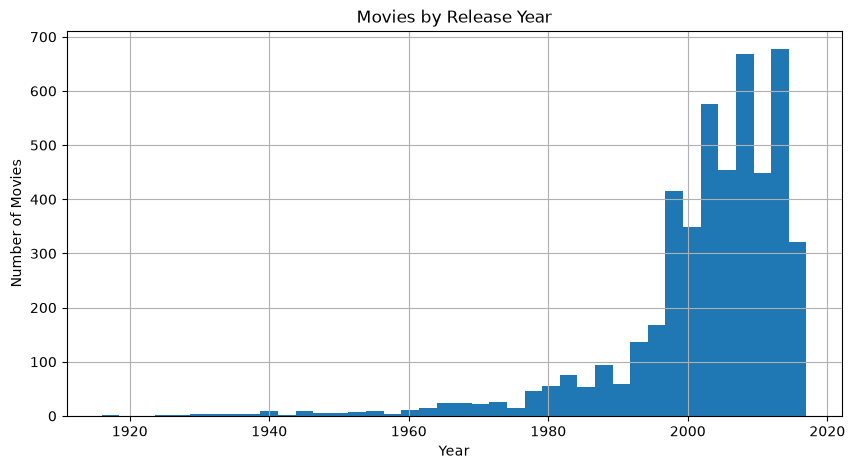

In [22]:
plt.figure(figsize=(10,5))

tmdb_movies["year"].hist(bins=40)

plt.title("Movies by Release Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

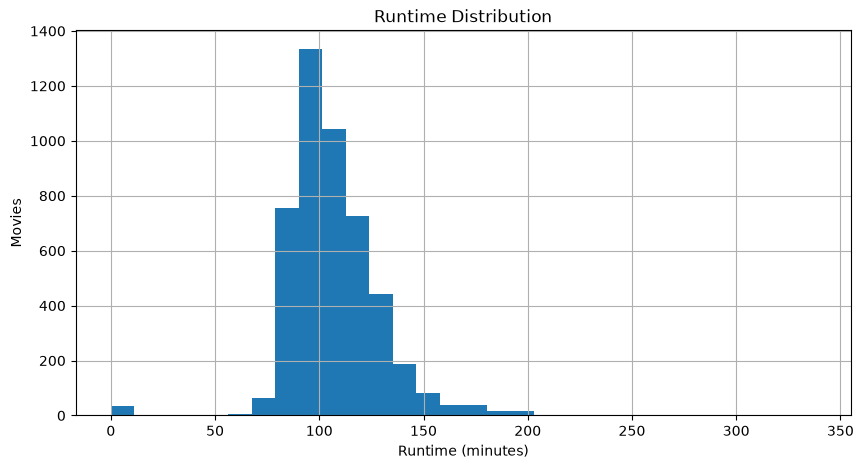

In [23]:
plt.figure(figsize=(10,5))

tmdb_movies["runtime"].hist(bins=30)

plt.title("Runtime Distribution")

plt.xlabel("Runtime (minutes)")

plt.ylabel("Movies")

plt.show()

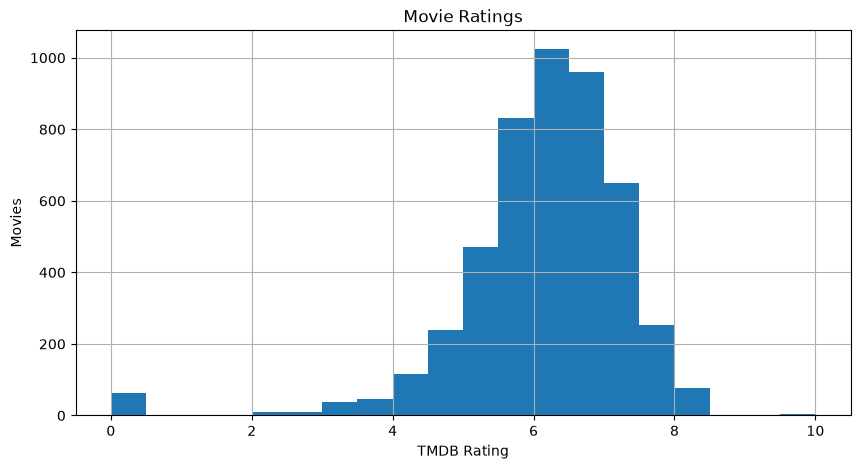

In [24]:
plt.figure(figsize=(10,5))

tmdb_movies["vote_average"].hist(bins=20)

plt.title("Movie Ratings")

plt.xlabel("TMDB Rating")

plt.ylabel("Movies")

plt.show()

In [25]:
tmdb_movies.nlargest(
    10,
    "popularity"
)[["title","popularity"]]

,title,popularity
546,Minions,875.581305
95,Interstellar,724.247784
788,Deadpool,514.569956
94,Guardians of the Galaxy,481.098624
127,Mad Max: Fury Road,434.278564
28,Jurassic World,418.708552
199,Pirates of the Caribbean: The Curse of the Bla...,271.972889
82,Dawn of the Planet of the Apes,243.791743
200,The Hunger Games: Mockingjay - Part 1,206.227151
88,Big Hero 6,203.734590


In [26]:
tmdb_movies.nlargest(
    10,
    "vote_average"
)[["title","vote_average"]]

,title,vote_average
3519,Stiff Upper Lips,10.0
4045,"Dancer, Texas Pop. 81",10.0
4247,Me You and Five Bucks,10.0
4662,Little Big Top,10.0
3992,Sardaarji,9.5
2386,One Man's Hero,9.3
1881,The Shawshank Redemption,8.5
2970,There Goes My Baby,8.5
2796,The Prisoner of Zenda,8.4
3337,The Godfather,8.4


# Feature Engineering

The recommendation model is trained using:

- Overview
- Genres
- Keywords
- Cast
- Director

These textual features are merged into a single representation and vectorized using TF-IDF.

In [27]:
movie_tags.columns

Index(['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew',
       'tags'],
      dtype='str')

In [28]:
movie_tags["tags"].head()

0    in the 22nd century, a paraplegic marine is di...
1    captain barbossa, long believed to be dead, ha...
2    a cryptic message from bond’s past sends him o...
3    following the death of district attorney harve...
4    john carter is a war-weary, former military ca...
Name: tags, dtype: str

In [29]:
movie_tags["tags"].str.split().str.len().describe()

count    4806.000000
mean       68.244694
std        28.677554
min         3.000000
25%        46.000000
50%        65.000000
75%        84.000000
max       202.000000
Name: tags, dtype: float64

## TF-IDF Representation

Each movie is represented as a weighted TF-IDF vector.

The vectors are compared using cosine similarity to identify semantically similar movies.

## Recommendation Pipeline

Raw Dataset

↓

Cleaning

↓

Feature Engineering

↓

TF-IDF

↓

Weighted Feature Matrix

↓

Cosine Similarity

↓

Top-N Recommendations

## Recommendation Quality

Metrics to evaluate:

- Similarity Score Distribution
- Genre Consistency
- Diversity
- Coverage
- Recommendation Case Studies

## Strengths

- Explainable recommendations
- No user history required
- Fast inference
- Metadata-rich recommendations

## Limitations

- No collaborative filtering
- Cold-start problem for new movies
- Depends on metadata quality
- Cannot personalize recommendations

## Future Work

- Hybrid recommendation system
- Sentence-BERT embeddings
- User personalization
- Collaborative filtering
- Approximate nearest-neighbor search

# Recommendation Model Evaluation

This section evaluates the trained recommendation engine using the saved similarity matrix.

In [44]:
movies = pd.read_pickle(BASE_DIR / "models/movies.pkl")

similarity = pd.read_pickle(BASE_DIR / "models/similarity.pkl")

print("Movies:", movies.shape)
print("Similarity Matrix:", similarity.shape)

Movies: (4806, 8)
Similarity Matrix: (4806, 4806)


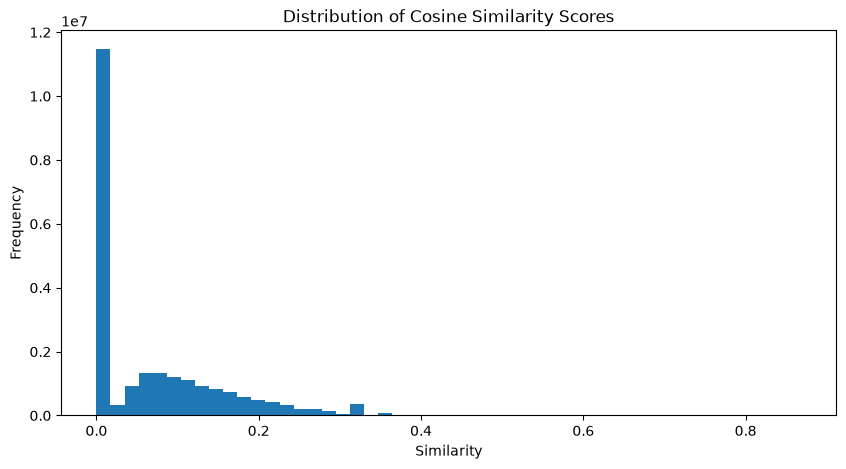

In [45]:
scores = similarity.flatten()

scores = scores[scores < 0.999]

plt.figure(figsize=(10,5))

plt.hist(scores, bins=50)

plt.title("Distribution of Cosine Similarity Scores")

plt.xlabel("Similarity")

plt.ylabel("Frequency")

plt.show()

In [46]:
scores.mean()

np.float64(0.0668684618035745)

Average similarity is relatively low, indicating that the model differentiates movies well rather than assigning uniformly high similarity scores.

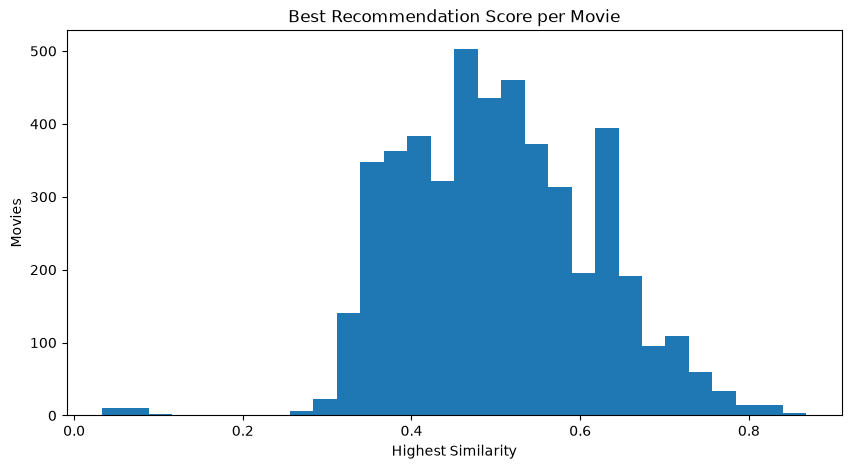

In [47]:
max_scores = []

for i in range(len(similarity)):
    max_scores.append(np.max(similarity[i][similarity[i] < 0.999]))

plt.figure(figsize=(10,5))

plt.hist(max_scores, bins=30)

plt.title("Best Recommendation Score per Movie")

plt.xlabel("Highest Similarity")

plt.ylabel("Movies")

plt.show()

In [48]:
recommended = set()

for row in similarity:

    indices = np.argsort(row)[::-1][1:11]

    recommended.update(indices)

coverage = len(recommended) / len(movies)

print(f"Coverage: {coverage:.2%}")

Coverage: 94.49%


In [49]:
diversity = []

for row in similarity:

    top10 = np.sort(row)[-11:-1]

    diversity.append(top10.std())

np.mean(diversity)

np.float64(0.053027286387600146)

In [50]:
sample_movies = [
    "Interstellar",
    "The Dark Knight",
    "Toy Story",
    "Avatar",
    "Titanic"
]

In [51]:
from src.recommender import recommend

for movie in sample_movies:

    print("=" * 80)

    print(movie)

    print()

    recs = recommend(movie)

    for r in recs[:5]:

        print(
            f"{r['title']} ({r['similarity']}%)"
        )

    print()

ModuleNotFoundError: No module named 'src'